In [4]:
import sys, os
# ensure parent directory is on the path so `src` package can be imported
sys.path.insert(0, os.path.abspath('..'))

In [5]:
# configura per importare da src
import sys
sys.path.append('./src')

## Box creation

### Load dataset

In [7]:
import re

concepts_file = '../AwA2_Dataset_Labels/Animals_with_Attributes2/extended_concepts.txt'
def parse_concepts(filepath):
    """Legge il file dei concetti e restituisce una lista ordinata."""
    concepts = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            # Rimuove eventuali tag come 
            line = re.sub(r'\\', '', line).strip()
            if not line:
                continue
            parts = line.split()
            # Assumiamo che il primo elemento sia l'ID e il resto il nome del concetto
            if len(parts) >= 2:
                concepts.append(parts[1])
    return concepts
concepts = parse_concepts(concepts_file)

In [8]:
import re

classes_file = '../AwA2_Dataset_Labels/Animals_with_Attributes2/classes.txt'
def parse_classes(filepath):
    """Legge il file delle classi e restituisce una lista ordinata."""
    classes = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            # Rimuove eventuali tag come 
            line = re.sub(r'\\', '', line).strip()
            if not line:
                continue
            parts = line.split()
            # Assumiamo che il primo elemento sia l'ID e il resto il nome della classe
            if len(parts) >= 2:
                classes.append(parts[1])
    return classes

classes = parse_classes(classes_file)

In [9]:
import json

JSON_PATH='../AwA2_Dataset_Labels/Animals_with_Attributes2/supervisioni_gerarchia.json'
def load_data(json_path, concepts):
    with open(json_path, 'r') as f:
        data = json.load(f)
        
    concept2id = {c: idx for idx, c in enumerate(concepts)}
    id2concept = {idx: c for c, idx in concept2id.items()}
    
    # Prepariamo il dataset nel formato [(id_i, id_j, label), ...]
    dataset = []
    for item in data:
        dataset.append((concept2id[item[0]], concept2id[item[1]], float(item[2])))
        
    return dataset, concept2id, id2concept

In [10]:
dataset, concept2id, id2concept = load_data(JSON_PATH, concepts)

### Train

In [11]:
from src.CHM.model import BoxHierarchyModel
from src.CHM.train import train_box
import torch.nn as nn
from torch.optim import Adam

LR = 0.05

box_model = BoxHierarchyModel(num_concepts=len(concept2id), dim=32)
optimizer = Adam(box_model.parameters(), lr=LR)
criterion = nn.BCELoss() # Binary Cross Entropy

In [12]:
train_box(box_model, optimizer, criterion, dataset, concept2id, id2concept)

Trovati 50 concetti unici e 583 relazioni supervisionate.

Inizio Addestramento...
Epoca [1/100] | Loss: 1.4952
Epoca [10/100] | Loss: 0.1920
Epoca [20/100] | Loss: 0.0553
Epoca [30/100] | Loss: 0.0207
Epoca [40/100] | Loss: 0.0098
Epoca [50/100] | Loss: 0.0060
Epoca [60/100] | Loss: 0.0043
Epoca [70/100] | Loss: 0.0036
Epoca [80/100] | Loss: 0.0031
Epoca [90/100] | Loss: 0.0028
Epoca [100/100] | Loss: 0.0026

Addestramento completato!

Verifica di alcune predizioni post-addestramento:
Relazione: Animal | arm
 - P_teorica: 1.0 -> P_predetta: 1.0000
Relazione: lower_body_part | big
 - P_teorica: 0.0 -> P_predetta: 0.0063
Relazione: yellow | wings
 - P_teorica: 0.0 -> P_predetta: 0.0000


### Visualization

In [13]:
from src.CHM.visualization import visualize_concept_hierarchy, visualize_heatmap_compare, visualize_all_boxes_2d

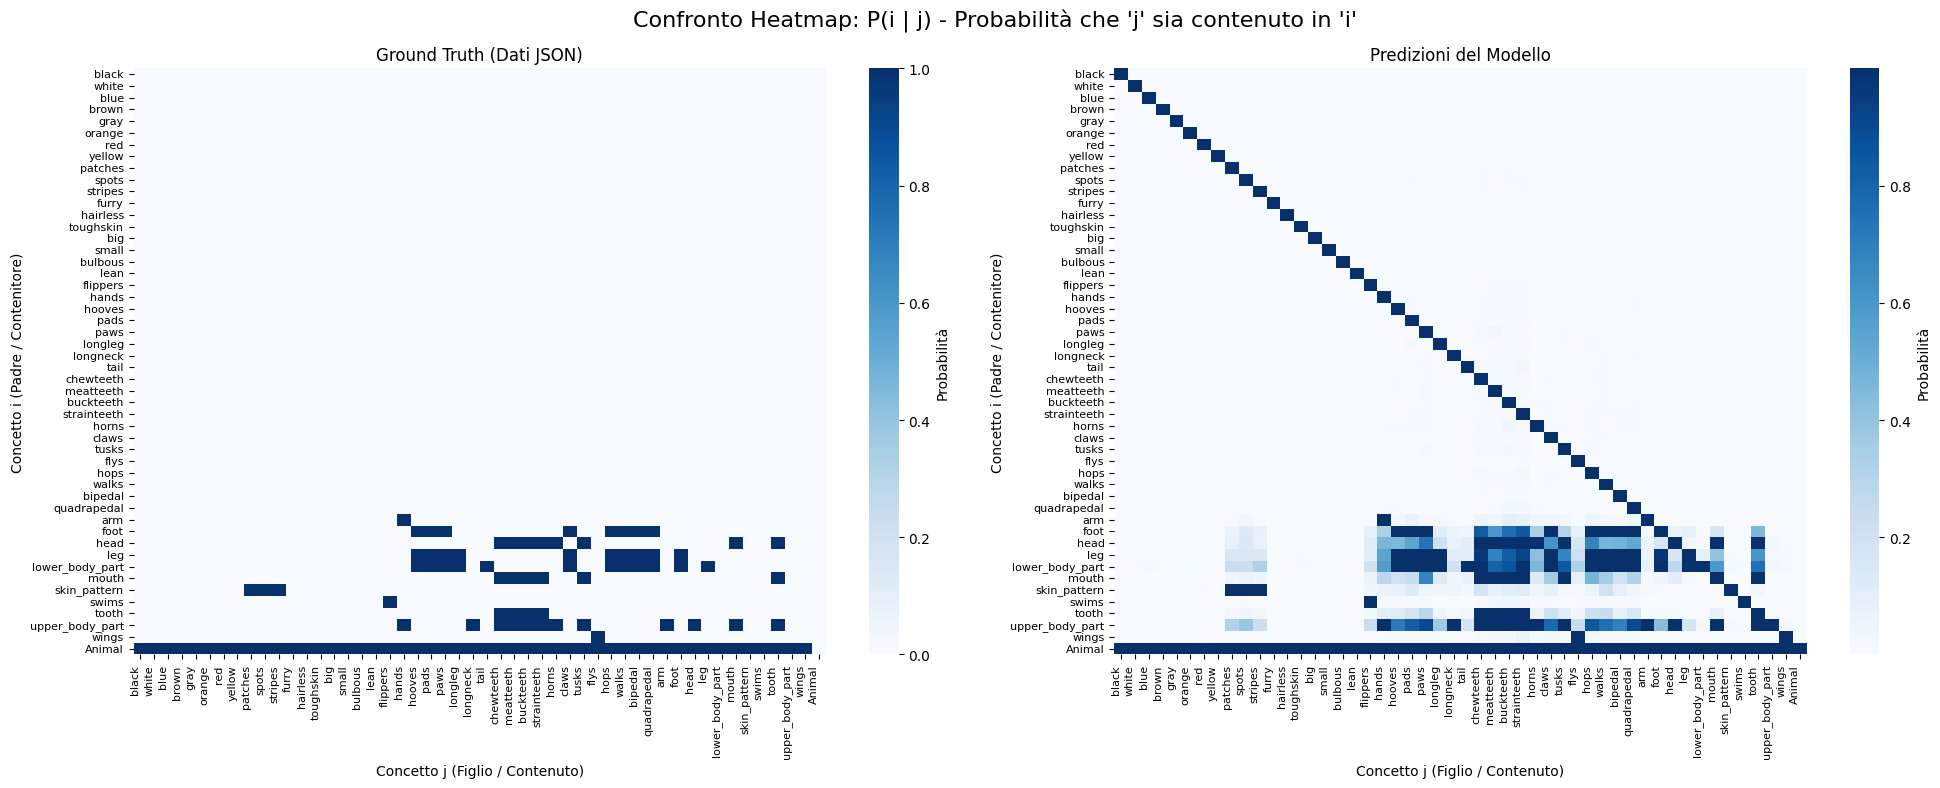

In [14]:
visualize_heatmap_compare(box_model, dataset, concept2id, id2concept)

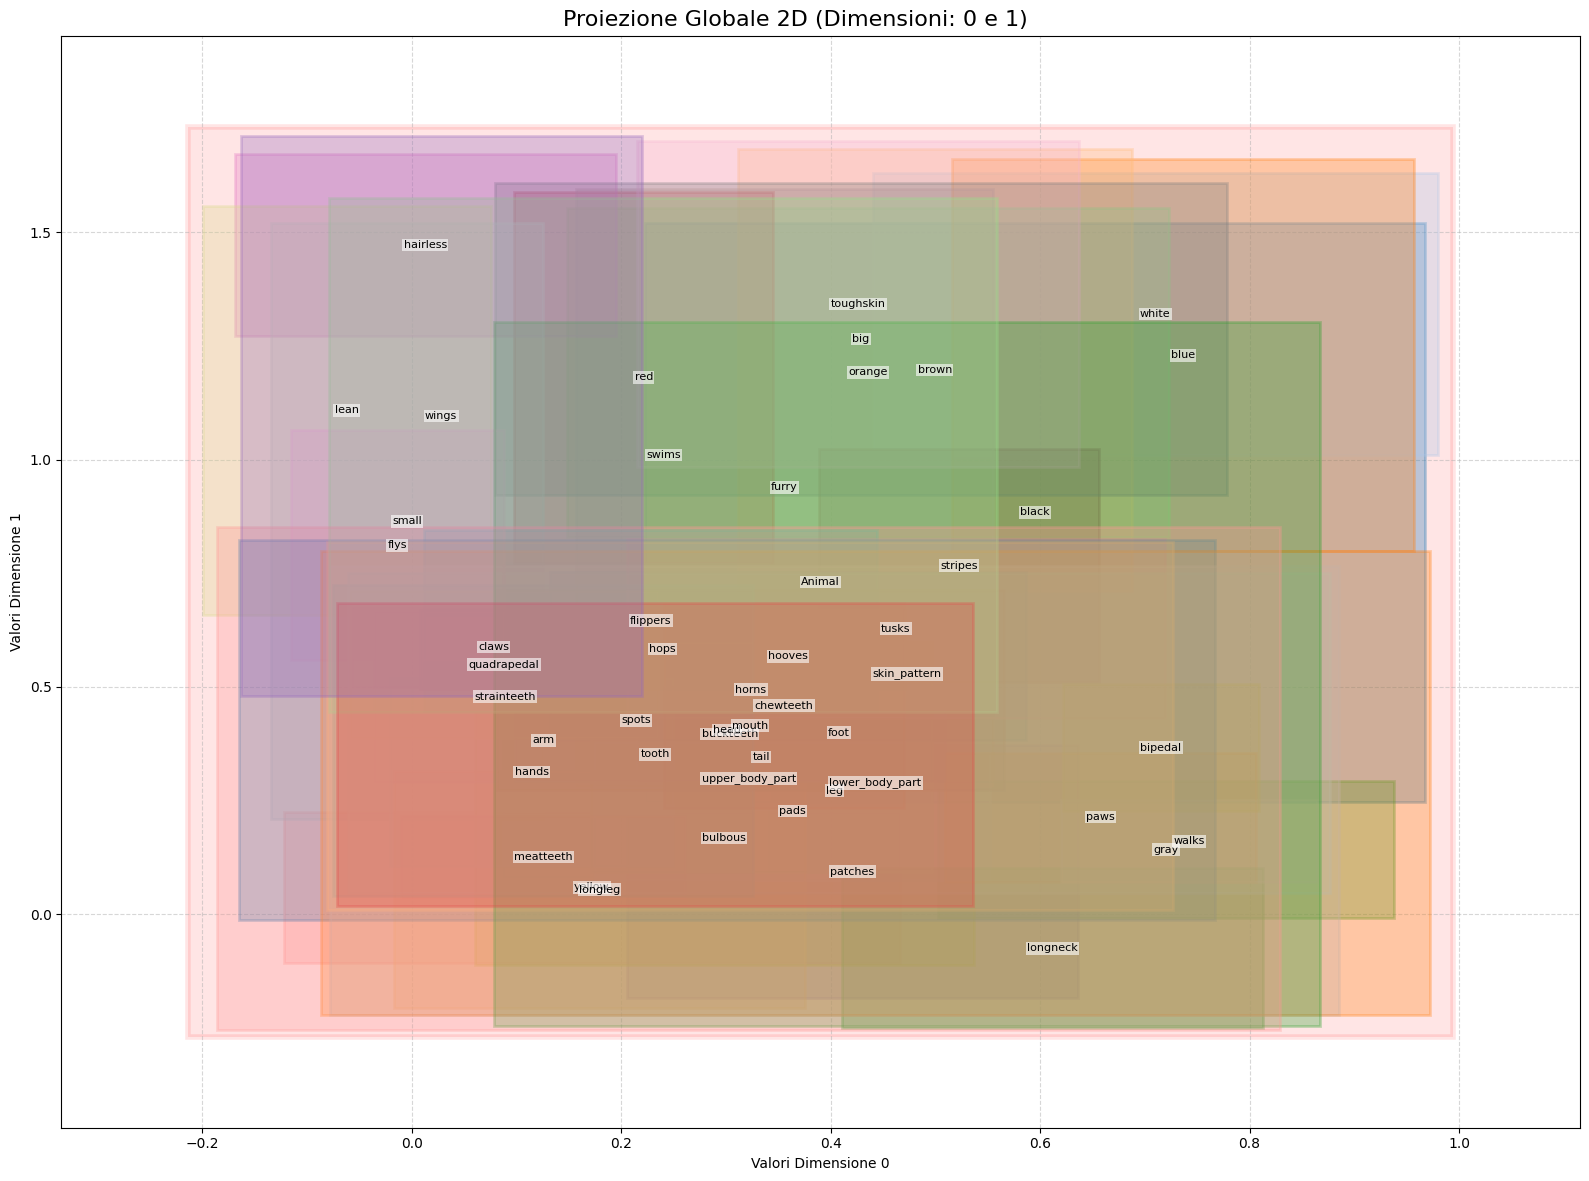

In [15]:
# cambiare dim_x e dim_y (da 0 a 31) per esplorare la "forma" da diverse angolazioni
visualize_all_boxes_2d(box_model, id2concept, dim_x=0, dim_y=1)

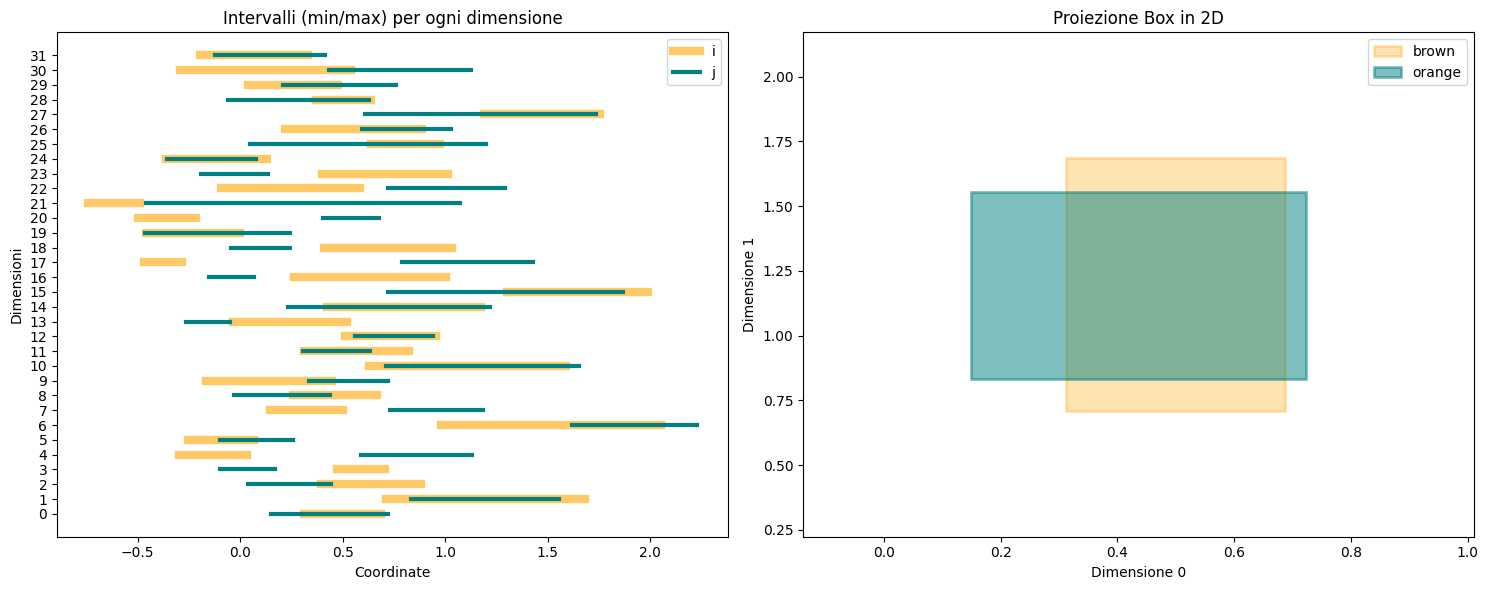

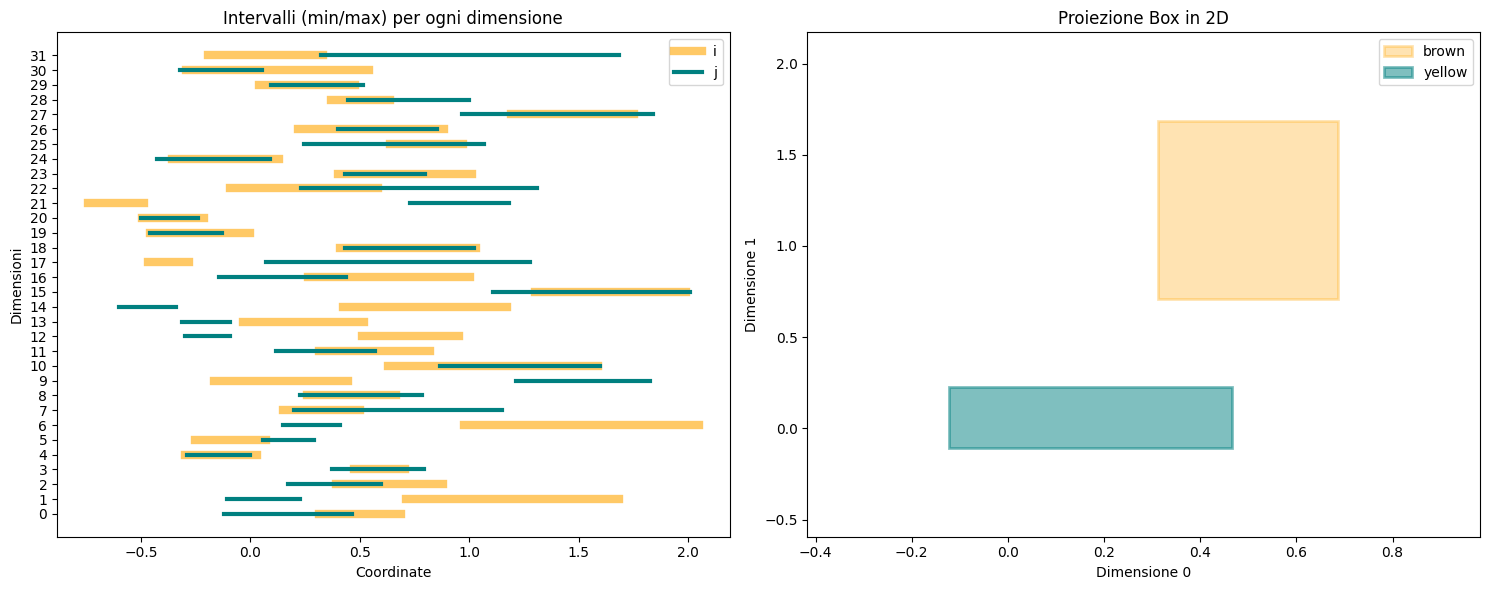

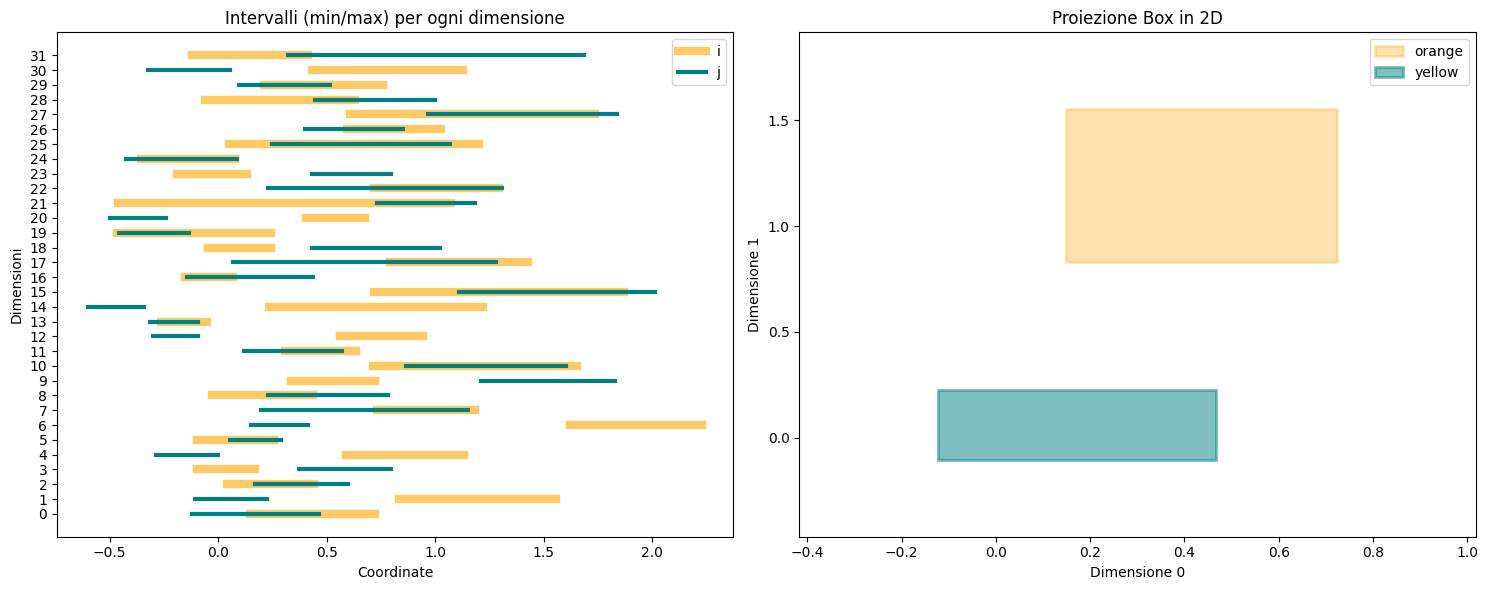

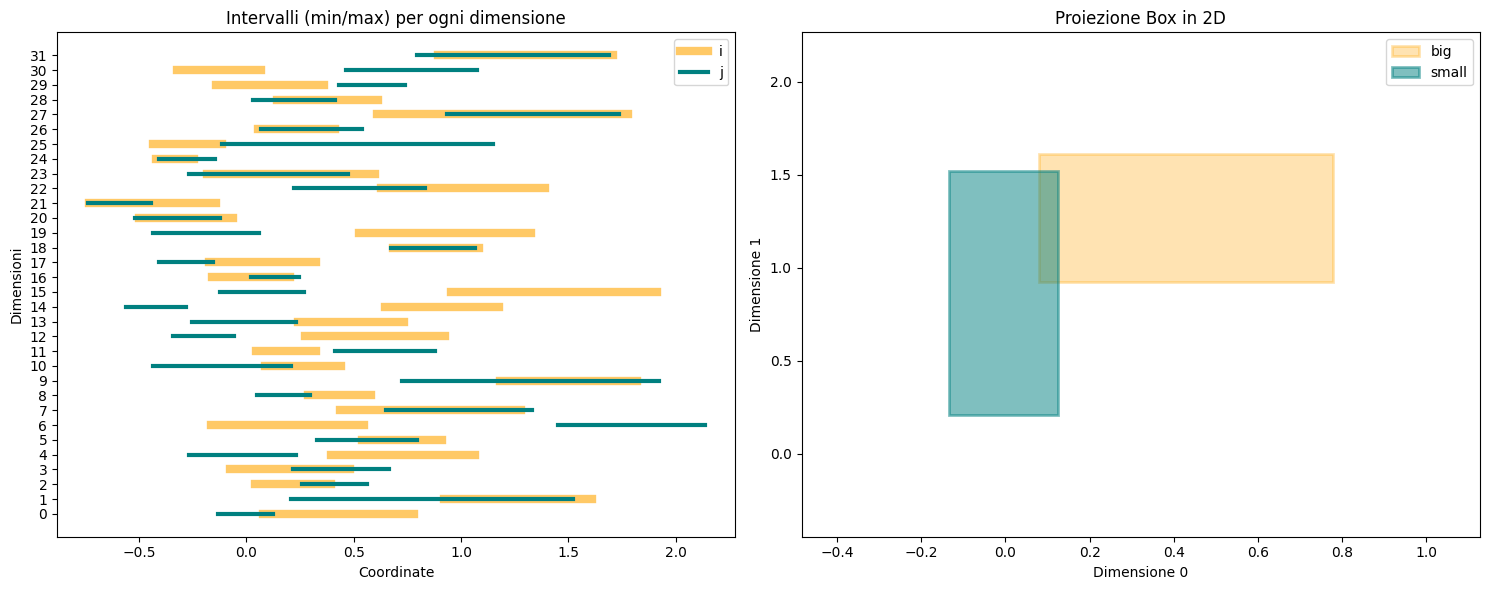

In [16]:
visualize_concept_hierarchy(box_model, id2concept, concept2id, "brown", "orange")
visualize_concept_hierarchy(box_model, id2concept, concept2id, "brown", "yellow")
visualize_concept_hierarchy(box_model, id2concept, concept2id, "orange", "yellow")
visualize_concept_hierarchy(box_model, id2concept, concept2id, "big", "small")

### Save boxes

In [17]:
from src.utils.box import get_box_dict

box_dict = get_box_dict(box_model, id2concept)

In [18]:
box_animale = box_dict["Animal"]
box_ali = box_dict["wings"]

print(f"Coordinate Z (max) per 'Animal': {box_animale.Z}")
print(f"Coordinate z (min) per 'wings': {box_ali.z}")

Coordinate Z (max) per 'Animal': tensor([[0.9947, 1.7321, 0.9898, 1.1561, 1.2178, 0.9572, 2.2440, 1.3314, 0.8479,
         1.9291, 1.7251, 1.0486, 1.0642, 0.8601, 1.2872, 2.0637, 1.2920, 1.4692,
         1.1747, 1.3849, 1.1805, 1.2566, 1.4143, 1.1049, 1.3007, 1.3334, 1.0374,
         1.8925, 1.1315, 1.0495, 1.1856, 1.8200]])
Coordinate z (min) per 'wings': tensor([[-0.1636,  0.4806,  0.1005, -0.0687, -0.0773, -0.0282, -0.0180, -0.3560,
         -0.2746, -0.2079,  0.4214, -0.1969, -0.0676, -0.1726,  0.1148, -0.2224,
         -0.1467,  0.4869,  0.0185, -0.0632,  0.0619, -0.7702,  0.0607, -0.2498,
          0.1443, -0.5293,  0.1436,  0.4302,  0.0255,  0.4062,  0.1800,  0.8154]])


## CBM

### Load dataset

In [19]:
import torch
torch.save(box_model.state_dict(), "modello_gerarchia.pth")

In [20]:
box_model.load_state_dict(torch.load("modello_gerarchia.pth"))

<All keys matched successfully>

In [21]:
from src.utils.dataset import classical_split_awa2_features
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from src.CBMGCN.model import ConceptGNNClassifier
from src.CBMGCN.train import train_gnn_cbm_classifier, sequential_training_gnn
import matplotlib.pyplot as plt
from src.utils.box import prepara_tensore_box, get_box_dict
from src.CP.model import ConceptPredictor
#from src.CHM.test import test_cbm_classifier, plot_test_results, test_sequential_cbm

In [22]:
box_dict = get_box_dict(box_model, id2concept)

In [23]:
box_animale = box_dict["Animal"]
box_ali = box_dict["wings"]

print(f"Coordinate Z (max) per 'Animal': {box_animale.Z}")
print(f"Coordinate z (min) per 'wings': {box_ali.z}")

Coordinate Z (max) per 'Animal': tensor([[0.9947, 1.7321, 0.9898, 1.1561, 1.2178, 0.9572, 2.2440, 1.3314, 0.8479,
         1.9291, 1.7251, 1.0486, 1.0642, 0.8601, 1.2872, 2.0637, 1.2920, 1.4692,
         1.1747, 1.3849, 1.1805, 1.2566, 1.4143, 1.1049, 1.3007, 1.3334, 1.0374,
         1.8925, 1.1315, 1.0495, 1.1856, 1.8200]])
Coordinate z (min) per 'wings': tensor([[-0.1636,  0.4806,  0.1005, -0.0687, -0.0773, -0.0282, -0.0180, -0.3560,
         -0.2746, -0.2079,  0.4214, -0.1969, -0.0676, -0.1726,  0.1148, -0.2224,
         -0.1467,  0.4869,  0.0185, -0.0632,  0.0619, -0.7702,  0.0607, -0.2498,
          0.1443, -0.5293,  0.1436,  0.4302,  0.0255,  0.4062,  0.1800,  0.8154]])


In [24]:
features_path = '../AwA2_Dataset_Features/Animals_with_Attributes2/Features/ResNet101/AwA2-features.txt'
labels_path = '../AwA2_Dataset_Features/Animals_with_Attributes2/Features/ResNet101/AwA2-labels.txt'

(X_train, y_train), (X_val, y_val), (X_test, y_test) = classical_split_awa2_features(
    features_path, labels_path, test_size=0.2, val_size=0.1, random_seed=42
)
class_concept_matrix = torch.from_numpy(np.loadtxt('../Awa2_Dataset_Labels/Animals_with_Attributes2/extended_matrix.txt', dtype=int))

box_tensors = prepara_tensore_box(box_dict, concept2id)

BOX_DIM = 32
BATCH_SIZE = 32
EPOCHS = 20
NUM_CLASSES = len(set(y_train))
NUM_CONCEPTS = len(concept2id)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

train_dataset = TensorDataset(torch.tensor(X_train).float(), torch.tensor(y_train).long())
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
val_dataset = TensorDataset(torch.tensor(X_val).float(), torch.tensor(y_val).long())
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, pin_memory=True)
test_dataset = TensorDataset(torch.tensor(X_test).float(), torch.tensor(y_test).long())
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, pin_memory=True)

Caricamento dei dati in corso... (potrebbe richiedere qualche secondo)
Dataset caricato correttamente: 37322 campioni con 2048 feature ciascuno.

--- Risultati dello Split Stratificato (50 Classi) ---
Training set:   26124 campioni
Validation set: 3733 campioni
Test set:       7465 campioni
Using device: cpu


### CBM with boxes

#### Train

In [27]:
b_cls = ConceptGNNClassifier(num_concepts=NUM_CONCEPTS, num_classes=NUM_CLASSES, in_features=box_tensors.shape[1], hidden_dim=64)
b_cls_optimizer = torch.optim.Adam(b_cls.parameters(), lr=0.001)
b_cls_criterion = nn.CrossEntropyLoss()

b_concept_predictor = ConceptPredictor(X_train.shape[1], num_concepts=NUM_CONCEPTS)
b_concept_optimizer = torch.optim.Adam(b_concept_predictor.parameters(), lr=0.001)
b_concept_criterion = nn.BCEWithLogitsLoss()

info = "boxes"

b_conc_history, b_cls_history = sequential_training_gnn(
    b_cls,
    b_concept_predictor,
    train_dataloader, 
    val_dataloader,
    class_concept_matrix,
    box_tensors,
    b_cls_optimizer,  
    b_concept_optimizer,
    b_cls_criterion,
    b_concept_criterion,
    EPOCHS, 
    device,
    info,
    bipolar=False,
)

========== FASE 1: Addestramento Predittore Concetti (h -> c) ==========
Loss: 3.5507 | Acc: 95.9470 || Val Loss: 2.5894 | Val Acc: 96.9746
Loss: 2.2512 | Acc: 97.4307 || Val Loss: 2.3602 | Val Acc: 97.2494
Loss: 1.9528 | Acc: 97.7659 || Val Loss: 2.2169 | Val Acc: 97.3935
Loss: 1.7741 | Acc: 97.9551 || Val Loss: 2.2199 | Val Acc: 97.4450
Loss: 1.6676 | Acc: 98.0759 || Val Loss: 2.1793 | Val Acc: 97.4942
Loss: 1.5674 | Acc: 98.1930 || Val Loss: 2.1555 | Val Acc: 97.4578
Loss: 1.4946 | Acc: 98.2732 || Val Loss: 2.1586 | Val Acc: 97.5076
Loss: 1.4269 | Acc: 98.3498 || Val Loss: 2.1505 | Val Acc: 97.5387
Loss: 1.3822 | Acc: 98.3982 || Val Loss: 2.1648 | Val Acc: 97.5060
Loss: 1.3360 | Acc: 98.4600 || Val Loss: 2.1902 | Val Acc: 97.5087
Loss: 1.2980 | Acc: 98.4988 || Val Loss: 2.1730 | Val Acc: 97.5516
Loss: 1.2687 | Acc: 98.5296 || Val Loss: 2.2009 | Val Acc: 97.4958
Loss: 1.2362 | Acc: 98.5730 || Val Loss: 2.2289 | Val Acc: 97.4910
Loss: 1.2047 | Acc: 98.6069 || Val Loss: 2.2574 | Val Ac

In [ ]:
from src.CHM.train import plot_history
plot_history(b_conc_history)

In [ ]:
plot_history(b_cls_history)

#### Test

In [ ]:
accuracy, preds, labels = test_sequential_cbm(
    b_cls,
    b_concept_predictor,
    test_dataloader,
    box_tensors,
    class_concept_matrix,
    device,
    info,
)

In [ ]:
plot_test_results(accuracy, preds, labels, class_names=classes)

In [ ]:
from src.CHM.interpretation import explain_prediction

explain_prediction(
    b_cls, 
    test_dataloader, 
    concepts, 
    classes, 
    class_concept_matrix, 
    box_tensors,
    concept_predictor=b_concept_predictor,
    target_class="ox"
)

### CBM with cond prob distrib

#### Train

In [ ]:
info = "rel_matrix"
bipolar = True
cp_model = ConceptBottleneckClassifier(box_dim=box_tensors.size(-1), num_classes=NUM_CLASSES, num_concepts=NUM_CONCEPTS, info=info)
optimizer = torch.optim.Adam(cp_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
cp_history = train_cbm_classifier(
    cp_model, 
    train_dataloader, 
    val_dataloader, 
    optimizer, 
    criterion, 
    class_concept_matrix, 
    box_tensors, 
    EPOCHS, 
    device,
    info=info,
    bipolar=bipolar
)

In [ ]:
from src.CHM.train import plot_history
plot_history(cp_history)

#### Test

In [ ]:
accuracy, preds, labels = test_cbm_classifier(
     model=cp_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     device="cuda" if torch.cuda.is_available() else "cpu",
     info=info,
     bipolar=bipolar,
     oracle=True,
)

In [ ]:
plot_test_results(accuracy, preds, labels, class_names=classes)

In [ ]:
from src.CHM.interpretation import explain_prediction

explain_prediction(
    cp_model, 
    test_dataloader, 
    concepts, 
    classes, 
    class_concept_matrix, 
    box_tensors, 
    info_type=info, 
    target_class="chihuahua", 
    bipolar=bipolar
)

### CBM standard

In [ ]:
info = "concepts"
c_model = ConceptBottleneckClassifier(box_dim=box_tensors.size(-1), num_classes=NUM_CLASSES, num_concepts=NUM_CONCEPTS, info=info)
optimizer = torch.optim.Adam(c_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
c_history = train_cbm_classifier(
    c_model, 
    train_dataloader, 
    val_dataloader, 
    optimizer, 
    criterion, 
    class_concept_matrix, 
    box_tensors, 
    EPOCHS, 
    device,
    info=info
)

In [ ]:
from src.CHM.train import plot_history
plot_history(c_history)

In [ ]:
accuracy, preds, labels = test_cbm_classifier(
     model=c_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     device="cuda" if torch.cuda.is_available() else "cpu",
     info=info,
     oracle=True,
)

In [ ]:
plot_test_results(accuracy, preds, labels, class_names=classes)

In [ ]:
from src.CHM.interpretation import explain_prediction

explain_prediction(c_model, test_dataloader, concepts, classes, class_concept_matrix, box_tensors, info_type=info)

In [ ]:
from src.CHM.interpretation import visualizza_separabilita, shuffle_test

visualizza_separabilita(
    model=c_model,
    test_dataloader=test_dataloader,
    class_concept_matrix=class_concept_matrix,
    boxes_tensor=box_tensors,
    info=info,
    bipolar=bipolar
)

In [ ]:
shuffle_test(c_model, test_dataloader, class_concept_matrix, box_tensors, info=info, bipolar=bipolar)

In [ ]:
from src.CHM.model import ConceptPredictor

concept_predictor = ConceptPredictor(X_train.shape[1], num_concepts=NUM_CONCEPTS)
optimizer = torch.optim.Adam(concept_predictor.parameters(), lr=0.001)
criterion = nn.BCEWithLogitsLoss()

In [ ]:
from src.CHM.train import train_concept_predictor

history = train_concept_predictor(
    concept_predictor, 
    train_dataloader, 
    val_dataloader, 
    class_concept_matrix, 
    optimizer, 
    criterion, 
    EPOCHS, 
    device
)

In [ ]:
info = "boxes"
b_accuracy, b_preds, b_labels = test_cbm_classifier(
     model=b_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     device="cuda" if torch.cuda.is_available() else "cpu",
     info=info,
     bipolar=False,
     oracle=False,
     concept_predictor=concept_predictor
)

In [ ]:
plot_test_results(b_accuracy, b_preds, b_labels, class_names=classes)

In [ ]:
info = "rel_matrix"
cp_accuracy, cp_preds, cp_labels = test_cbm_classifier(
     model=cp_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     device="cuda" if torch.cuda.is_available() else "cpu",
     info=info,
     bipolar=False,
     oracle=False,
     concept_predictor=concept_predictor
)

In [ ]:
plot_test_results(cp_accuracy, cp_preds, cp_labels, class_names=classes)

In [ ]:
info = "concepts"
c_accuracy, c_preds, c_labels = test_cbm_classifier(
     model=c_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     device="cuda" if torch.cuda.is_available() else "cpu",
     info=info,
     bipolar=False,
     oracle=False,
     concept_predictor=concept_predictor
)

In [ ]:
plot_test_results(c_accuracy, c_preds, c_labels, class_names=classes)

In [ ]:
for f, l in test_dataloader:
    print(f"Batch features shape: {f.shape}, Batch labels shape: {l.shape}")
    print(l)
    break

In [ ]:
matrix = torch.tensor([[0, 1, 0], [1, 0, 1], [1, 1, 0], [0, 0, 1]])  # Esempio di matrice
print(matrix)
l = torch.tensor([0, 1, 1, 3, 2]).view(-1)
c = matrix[l]
print(c, c.shape)

In [ ]:
c_flat = c.view(c.size(0), -1)  # Reshape per linear layer
print(c_flat, c_flat.shape)

In [ ]:
ll = nn.Linear(3, 5)
y = ll(c.float())

In [ ]:
y